In [1]:
import torch
from neural_lam.weather_dataset import WeatherDataset

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(0)
standardize = True

dataset = WeatherDataset(
            "meps_example",
            pred_length=1,
            split="train",
            subsample_step=3,
            subset=bool(0),
            control_only=0,
            standardize=standardize,
            border_condition=True
        )

sample_idx = 0 # torch.randint(len(dataset), size=(1,)).item()
init_states, target_states, forcing, boundary_forcing = dataset[sample_idx]

print(f"init_states shape: {init_states.shape}")
print(f"target_states shape: {target_states.shape}")
print(f"forcing shape: {forcing.shape}")
print(f"boundary_forcing shape: {boundary_forcing.shape}")

/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/utils.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(
/proj/berzelius-2022-164/users/x_e

Loading sample from /proj/berzelius-2022-164/weather/neural_lam_datasets/meps_example/samples/train/nwp_2022040100_mbr000.npy
Sample name: 2022040100_mbr000
index: 0
init_states shape: torch.Size([2, 54064, 17])
target_states shape: torch.Size([1, 54064, 17])
forcing shape: torch.Size([1, 54064, 16])
boundary_forcing shape: torch.Size([1, 9720, 67])


In [2]:
len(dataset)

4

In [14]:
from neural_lam import utils, config

static_data_dict = utils.load_static_data("meps_example")
data_config = config.Config.from_file("neural_lam/data_config.yaml")

# torch.set_printoptions(precision=3, sci_mode=False)
# np.set_printoptions(precision=18, suppress=False, floatmode="maxprec")

for key, value in static_data_dict.items():
    print(f"{key}: {value}")

boundary_mask: tensor([True, True, True,  ..., True, True, True])
interior_mask: tensor([False, False, False,  ..., False, False, False])
grid_static_features: tensor([[-0.718, -0.922,  0.027,  0.000],
        [-0.710, -0.922,  0.014,  0.000],
        [-0.703, -0.922,  0.014,  0.000],
        ...,
        [ 0.890,  0.925,  0.014,  0.000],
        [ 0.897,  0.925,  0.014,  0.000],
        [ 0.905,  0.925,  0.014,  0.000]])
boundary_static_features: tensor([[-0.793, -0.996,  0.014,  1.000],
        [-0.785, -0.996,  0.013,  1.000],
        [-0.778, -0.996,  0.014,  1.000],
        ...,
        [ 0.964,  1.000,  0.169,  1.000],
        [ 0.972,  1.000,  0.118,  1.000],
        [ 0.979,  1.000,  0.109,  1.000]])
step_diff_mean: tensor([-0.018, -0.058,  0.010,  0.000,  0.008,  0.006,  0.012,  0.012, -0.003,
         0.014,  0.002,  0.017,  0.016,  0.005,  0.011, -0.057, -0.027])
step_diff_std: tensor([0.046, 0.148, 0.672, 0.879, 0.667, 0.660, 0.379, 0.343, 0.126, 0.185,
        0.429, 0.369

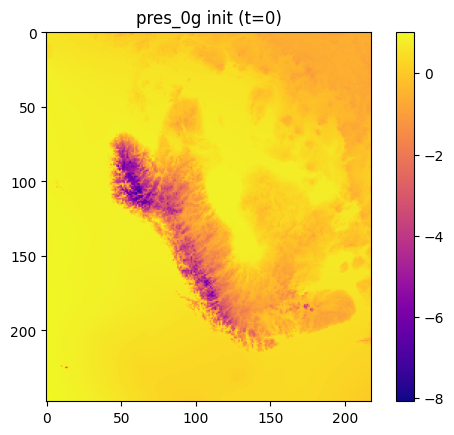

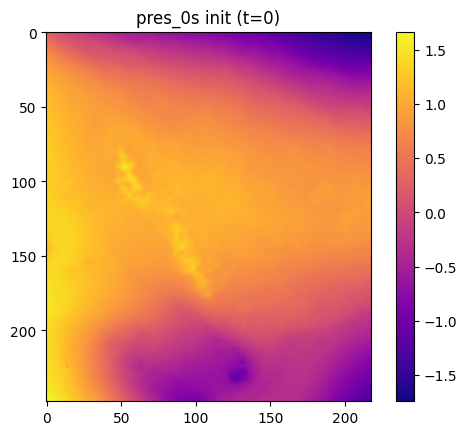

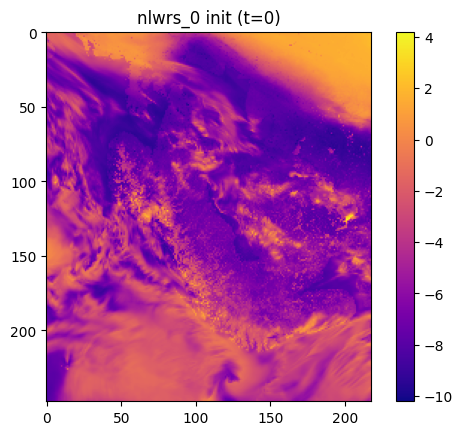

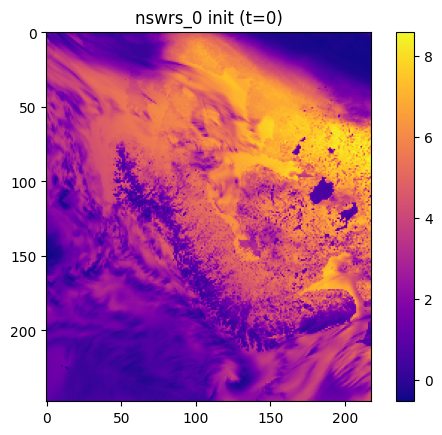

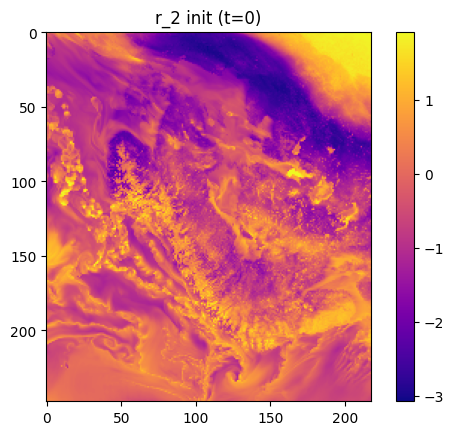

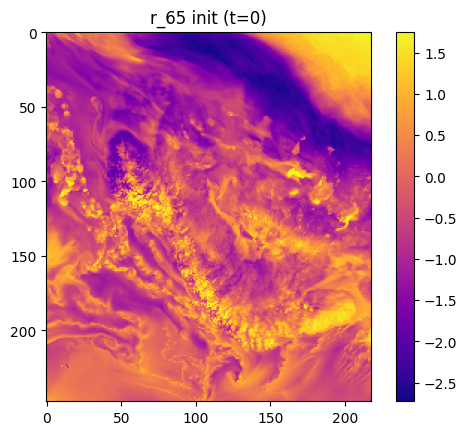

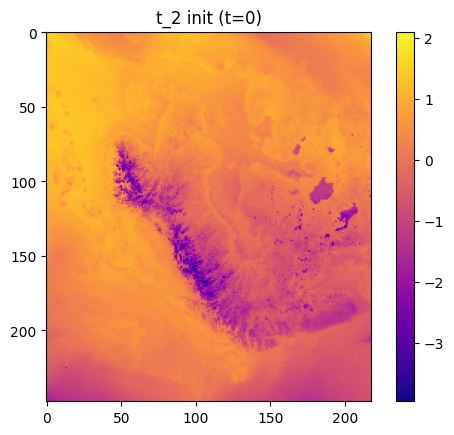

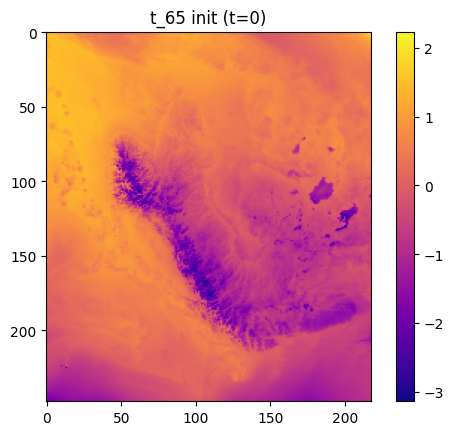

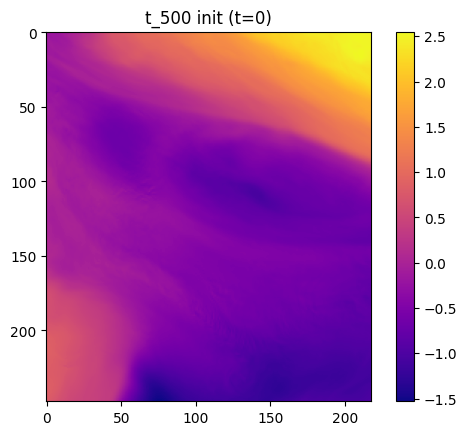

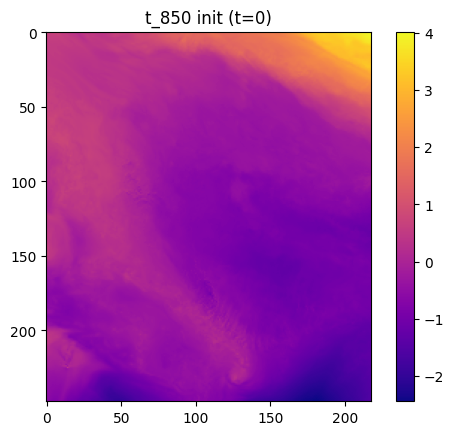

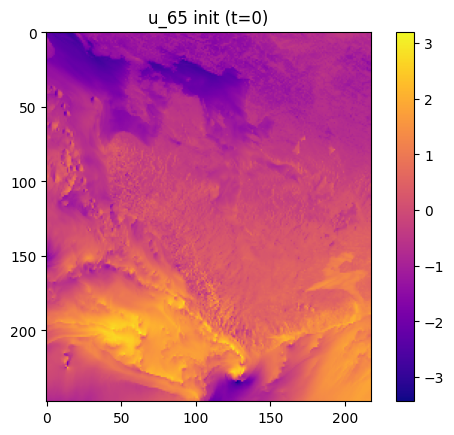

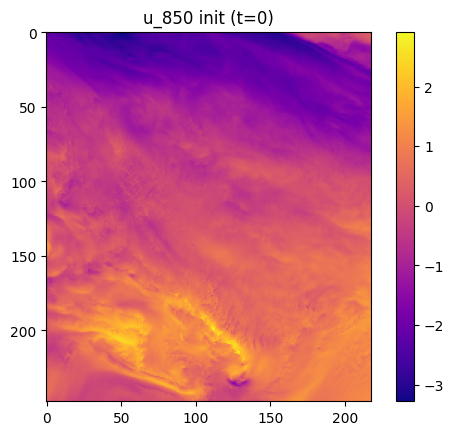

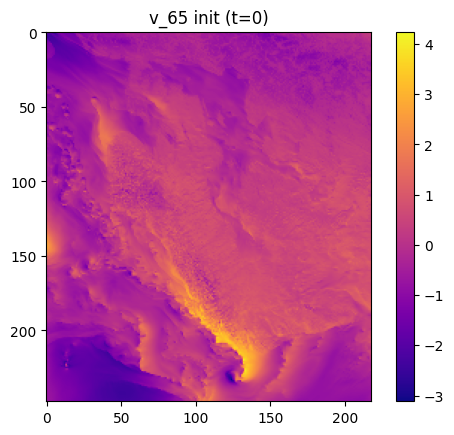

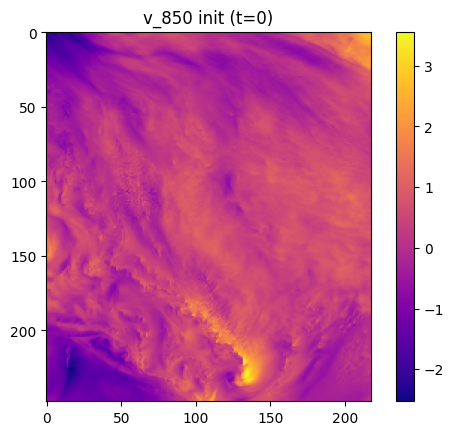

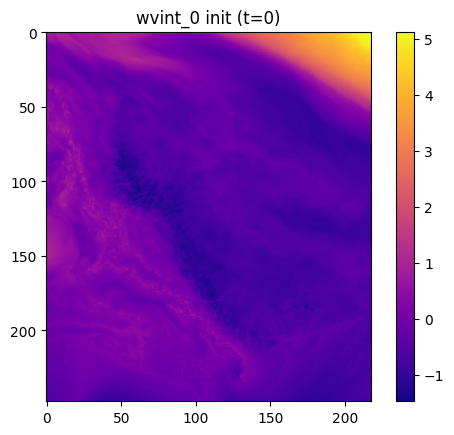

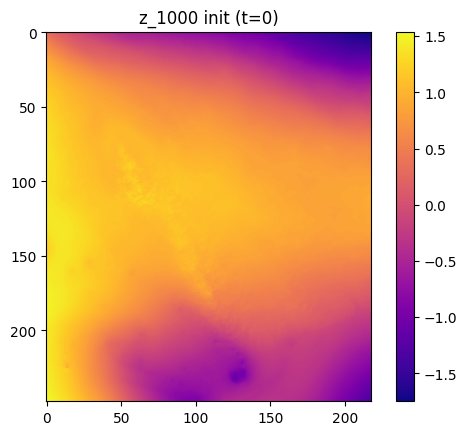

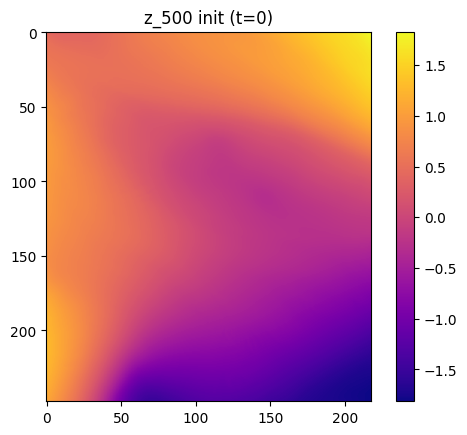

In [4]:
import matplotlib.pyplot as plt
import os
GRID_SHAPE = (248, 218)  # (y, x) without border
FULL_GRID_SHAPE = (268, 238)

time_idx = 0  # choose which timestep to plot
output_dir = "./state_debug_OG"
if standardize:
    output_dir += "_standardized"
os.makedirs(output_dir, exist_ok=True)
for var_idx, var_name in enumerate(data_config.dataset.var_names):
    # init_states assumed shape (T, N, V) -> reshape to (T, Y, X, V)
    # arranged = init_states.reshape(init_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)
    arranged = target_states.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)

    img = arranged[time_idx, ..., var_idx]
    torch.save(img, os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.pt"))
    img = img.cpu().numpy() if hasattr(img, "cpu") else img.numpy()

    plt.figure()
    plt.imshow(img, cmap="plasma")
    plt.title(f"{var_name} init (t={time_idx})")
    plt.colorbar()
    plt.savefig(os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.png"))